Contenido bajo licencia Creative Commons BY 4.0 y código bajo licencia MIT. © Nicolás Guarín-Zapata 2026.

# Elementos finitos en 2D

Queremos resolver la ecuación de onda

$$\nabla^2 u(\mathbf{x, t}) = \frac{\partial^2 u(\mathbf{x,t})}{\partial t^2} - f(\mathbf{x})\quad
\forall \mathbf{x}\in \Omega \, , \forall t \in (0, T)$$

con

$$u(\mathbf{x}, t) = 0\quad \forall \mathbf{x} \in \partial\Omega\, , \forall t \in (0, T)$$

y

\begin{align*}
u(\mathbf{x}, 0) = u_0\quad \forall \mathbf{x} \in \Omega\, ,\\
\frac{\partial u(\mathbf{x}, 0)}{\partial t} = v_0\quad \forall \mathbf{x} \in \Omega\, .
\end{align*}

Vamos a usar una solución aproximada de la forma

$$u(\mathbf{x}) = \sum_{n=0}^{N} u_n \phi_n(\mathbf{x})\, .$$

Si usamos el método de Galerkin, la ecuación diferencial es equivalente
al siguiente problema variacional

$$-\int\limits_\Omega (\nabla u) \cdot (\nabla \phi_n) d\Omega
= \int\limits_\Omega  \phi_n \frac{\partial^2 u}{\partial t^2} d\Omega
-\int\limits_\Omega  \phi_n f d\Omega\, \quad \forall \phi_n\, .$$

Si remplazamos $u(x)$ en este sistema obtenemos

$$-\sum_{j=0}^N \left[\int\limits_\Omega (\nabla \phi_i) \cdot (\nabla \phi_j) d\Omega\right] u_j
= \sum_{j=0}^N \left[\int\limits_\Omega \phi_i \phi_j dx\right] \frac{\partial^2 u_j}{\partial t^2}
- \int\limits_\Omega  \phi_j f d\Omega\, \quad \forall \phi_j\, .$$

Esto lleva al siguiente sistema de ecuaciones

$$[M]\{\ddot{\mathbf{u}}\} + [K]\{\mathbf{u}\} + \{\mathbf{b}\} = \{\mathbf{0}\}$$

Usando triángulos lineales, las matrices de rigidez son

$$K_\text{local} =  \frac{|J|}{2} (J^{-1}D)^T (J^{-1}D)\, ,$$


$$b_\text{local} = \frac{|J| f(\mathbf{x}_m)}{6} 
\begin{bmatrix}1\\ 1\\ 1 \end{bmatrix}\, ,$$

y

$$M_\text{local} = \frac{|J|}{24}
\begin{bmatrix}
2 & 1 & 1\\
1 & 2 & 1\\
1 & 1 & 2\end{bmatrix}\, ,$$

donde $|J|$ es el determinante jacobiano de la transformación y
$\mathbf{x}_m$ es el centroide del triángulo. Acá asumismos que
el término fuente era constante en el elemento.

## Integración en el tiempo

El sistema

$$[M]\{\ddot{\mathbf{u}}\} + [K]\{\mathbf{u}\} + \{\mathbf{b}\}
= \{\mathbf{0}\}\, ,$$

es un sistema de ecuaciones diferenciales ordinarias. Para resolverlo
podemos usar algún método de integración en el tiempo.

Por ejemplo, podemos expandir la derivada en el tiempo en una
diferencia finita centrada para obtener

$$\frac{1}{\Delta t^2}[M]\{\mathbf{u}^{n + 1} - 2\mathbf{u}^{n} +  \mathbf{u}^{n- 1}\} + [K]\{\mathbf{u}^n\} +\{\mathbf{b}\} = \{\mathbf{0}\}\, ,$$

o

$$[M]\{\mathbf{u}^{n + 1}\} = [M]\left(2\{\mathbf{u}^{n}\} - \{\mathbf{u}^{n- 1}\}\right)- \Delta t^2\left([K]\{\mathbf{u}^n\} +\{\mathbf{b}\}\right)\, ,\quad \forall n>1.$$

Para la primera iteración podemos usar una diferencia finita hacia adelante

$$\{\mathbf{u}^1\} = \{\mathbf{u}^0\} + \Delta t \{\dot{\mathbf{u}}^0\}\, .$$

In [1]:
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
%matplotlib widget

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import meshio

In [4]:
# Configuracion graficos
gris = '#757575'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["text.color"] = gris
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.color"] = gris
plt.rcParams["ytick.color"] = gris
plt.rcParams["axes.labelcolor"] = gris
plt.rcParams["axes.edgecolor"] = gris
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

In [5]:
def assem(coords, elems, source):
    """
    Ensambla la matriz de rigidez y el vector de cargas
    
    Parámetros
    ----------
    coords : ndarray, float
        Coordenadas de los nodos.
    elems : ndarray, int
        Conectividad de los elementos.
    source : ndarray, float
        Término fuente evaluado en los nodos de la malla.
    
    Retorna
    -------
    stiff : ndarray, float
        Matriz de rigidez del problema.
    mass : ndarray, float
        Matriz de masa del problema.
    rhs : ndarray, float
        Vector de cargas del problema.
    """
    ncoords = coords.shape[0]
    stiff = np.zeros((ncoords, ncoords))
    mass = np.zeros((ncoords, ncoords))
    rhs = np.zeros((ncoords))
    for el_cont, elem in enumerate(elems):
        stiff_loc, mass_loc, det = local_mat(coords[elem])
        rhs[elem] += det*np.mean(source[elem])/6
        for row in range(3):
            for col in range(3):
                row_glob, col_glob = elem[row], elem[col]
                stiff[row_glob, col_glob] += stiff_loc[row, col]
                mass[row_glob, col_glob] += mass_loc[row, col]
    return stiff, mass, rhs

In [6]:
def local_mat(coords):
    """Calcula la matriz de rigidez local
        
    Parámetros
    ----------
    coords : ndarray, float
        Coordenadas de los nodos del elemento.
    
    Retorna
    -------
    stiff : ndarray, float
        Matriz de rigidez local.
    det : float
        Determinante del jacobian.
    mass : float
        Matriz de masa local.
    """
    dNdr = np.array([
            [-1, 1, 0],
            [-1, 0, 1]])
    jaco = dNdr @ coords
    det = np.linalg.det(jaco)
    jaco_inv = np.linalg.inv(jaco)
    dNdx = jaco_inv @ dNdr
    stiff = 0.5 * det * (dNdx.T @ dNdx)
    mass = det/24 * np.array([
            [2.0, 1.0, 1.0],
            [1.0, 2.0, 1.0],
            [1.0, 1.0, 2.0]])
    return stiff, mass, det

In [7]:
def pts_restringidos(coords, malla, lineas_rest):
    """
    Identifica los nodos restringidos y libres
    para la malla.
        
    Parámetros
    ----------
    coords : ndarray, float
        Coordenadas de los nodos del elemento.
    malla : Meshio mesh
        Objeto de malla de Meshio.
    lineas_rest : list
        Lista con los números para las líneas
        restringidas.
    
    Retorna
    -------
    pts_rest : list
        Lista de puntos restringidos.
    pts_libres : list
        Lista de puntos libres.
    """
    lineas = [malla.cells[k].data for k in lineas_rest]
    pts_rest = []
    for linea in lineas:
        pts_rest += set(linea.flatten())
    pts_libres = list(set(range(coords.shape[0])) - set(pts_rest))
    return pts_rest, pts_libres

## Ejemplo

En este caso leemos una malla de Gmsh usando ``meshio``.

In [8]:
malla = meshio.read("cuadrado51.msh")

Para este ejemplo los triángulos están en la
posición ``4`` de las celdas de la malla.

In [9]:
pts = malla.points
x, y = pts[:, 0:2].T
tri = malla.cells[4].data

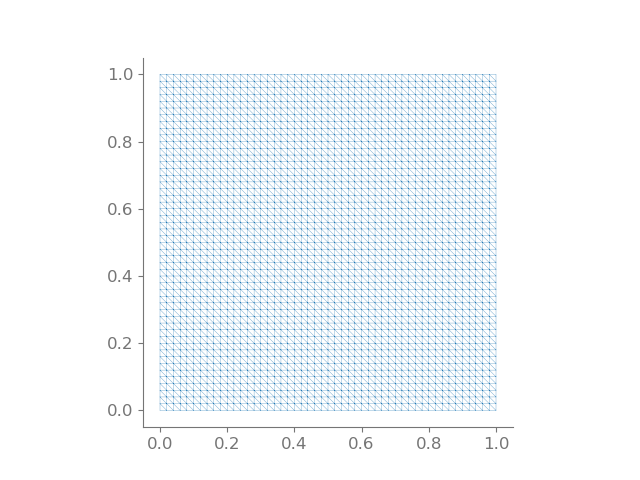

In [10]:
plt.figure()
plt.triplot(x, y, tri, linewidth=0.2)
plt.axis("image")
plt.show()

In [11]:
fuente = np.zeros_like(x)
stiff, mass, rhs = assem(pts[:, :2], tri, fuente)

Podemos probar con diferentes condiciones iniciales. Si seleccionamos

$$u_0 = \sin(m\pi x) \sin(n\pi y)\, ,$$

la forma de la solución no debería cambiar con el tiempo y sólo debería
verse afectada su amplitud.

In [12]:
cond_ini = "vector_propio"


if cond_ini == "vector_propio":
    u_ini = np.sin(2*np.pi*x) * np.sin(3*np.pi*y)
    v_ini = np.zeros_like(u_ini)
else:
    u_ini = np.exp( -100*(x - 0.5)**2 - 100*(y - 0.5)**2)
    v_ini = np.zeros_like(u_ini)

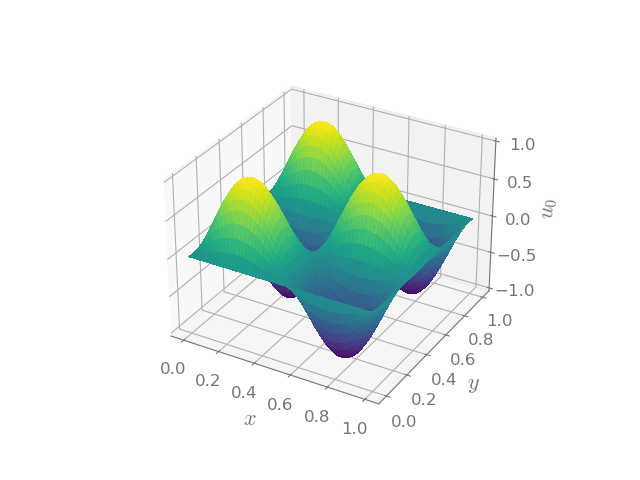

In [23]:
fig0 = plt.figure()
ax0 = fig0.add_subplot(projection='3d')
ax0.plot_trisurf(x, y, u_ini, triangles=tri, cmap="viridis", antialiased=False)
ax0.set_xlabel(r"$x$", fontsize=16)
ax0.set_ylabel(r"$y$", fontsize=16)
ax0.set_zlabel(r"$u_0$", fontsize=16)
plt.show()

Tenemos una función que nos permite identificar los nodos
que están restringidos y los que están libres.

In [14]:
pts_rest, pts_libres = pts_restringidos(pts, malla, [0, 1, 2, 3])

In [15]:
dt = 0.005
niter = 500

In [16]:
u_total = np.zeros((x.shape[0], niter))
u_total[:, 0] = u_ini
u_total[:, 1] = u_ini + dt*v_ini

Y resolvemos.

In [18]:
M = mass[np.ix_(pts_libres, pts_libres)]
for cont in range(1, niter - 1):
    rhs = mass @ (2*u_total[:, cont] - u_total[:, cont - 1]) - dt**2*(stiff @ u_total[:, cont] + fuente)
    sol_aux = np.linalg.solve(M, rhs[pts_libres])
    u_total[pts_libres, cont + 1] = sol_aux

### Animación

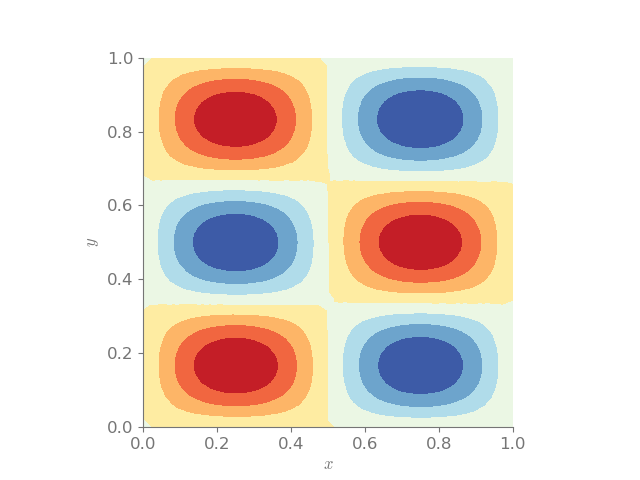

In [21]:

fig, ax = plt.subplots()

ims = []
for cont in range(niter):
    im = ax.tricontourf(x, y, u_total[:, cont], cmap="RdYlBu", vmin=-1, vmax=1)
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.axis("image")
    if cont == 0:
        im = ax.tricontourf(x, y, u_total[:, 0], cmap="RdYlBu", vmin=-1, vmax=1)
        plt.xlabel("$x$")
        plt.ylabel("$y$")
        plt.axis("image")
    ims.append([im])


ani = animation.ArtistAnimation(fig, ims, blit=True)